# Lab 1: Image Representation and Basic Operations
`By: Raman Shakya (022bscit033)`

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [30]:
def plot(rows, cols, images, titles):
    plt.figure(figsize=(10,10))
    for i in range(rows):
        for j in range(cols):
            plt.subplot(rows, cols, i * cols + j + 1)
            plt.imshow(images[i*cols+j], cmap='gray')
            plt.title(titles[i*cols+j])

## Image Creation and Image Display

In [14]:
WIDTH = 256
HEIGHT = 256
def createImage():
    img = np.zeros((WIDTH, HEIGHT), dtype=np.uint8)

    for i in range(HEIGHT):
        for j in range(WIDTH):
            img[i,j] = np.random.randint(0, 255)

    return img

In [15]:
def displayImage(img):
    plt.imshow(img, cmap='gray')

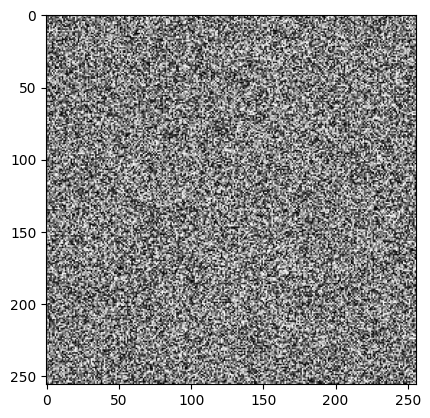

In [16]:
img = createImage()
displayImage(img)

## Accessing Image Properties

In [17]:
print("shape:", img.shape)
print("size:", img.size)
print("dtype:", img.dtype)

shape: (256, 256)
size: 65536
dtype: uint8


## Color Space Conversion

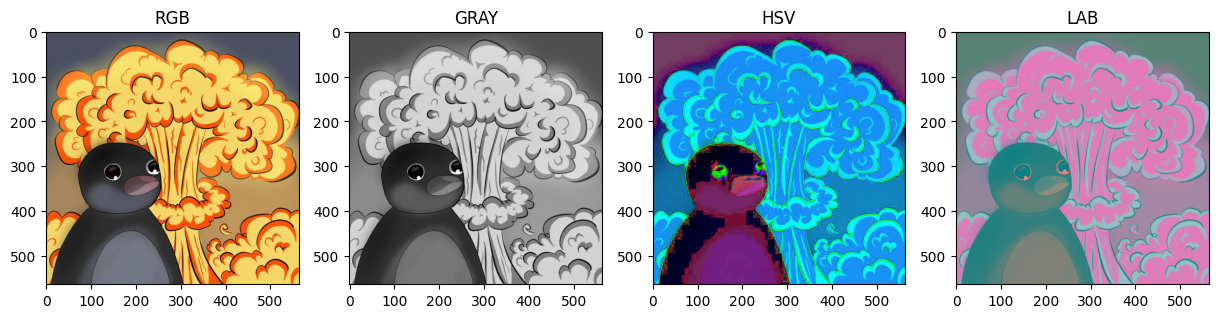

In [18]:
img = cv2.imread('wow.png')
plt.figure(figsize=(15, 15))

for i,color in enumerate(["RGB", "GRAY", "HSV", "LAB"]):
    plt.subplot(1,4,i+1)
    plt.imshow(cv2.cvtColor(img, eval(f'cv2.COLOR_BGR2{color}')), cmap='gray')
    plt.title(color)

## Sampling and Quantization

In [32]:
def circle(x, y, r, h, k):
    distance = np.sqrt((x-h)**2 + (y-k)**2)
    if distance < r: return 255 - distance / r * 255
    return 0

def createCircle(w=128, h=128):
    img = np.zeros((w, h), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            img[i, j] = circle(i, j, h//3, w//2, h//2)
    return img

In [37]:
def sampleCircle(img, w, h):
    xFactor = len(img)//w
    yFactor = len(img)//h
    return img[::xFactor, ::yFactor]

In [34]:
def quantize(img, div=8):
    img = np.floor(img / 255 * div) * 255
    return img

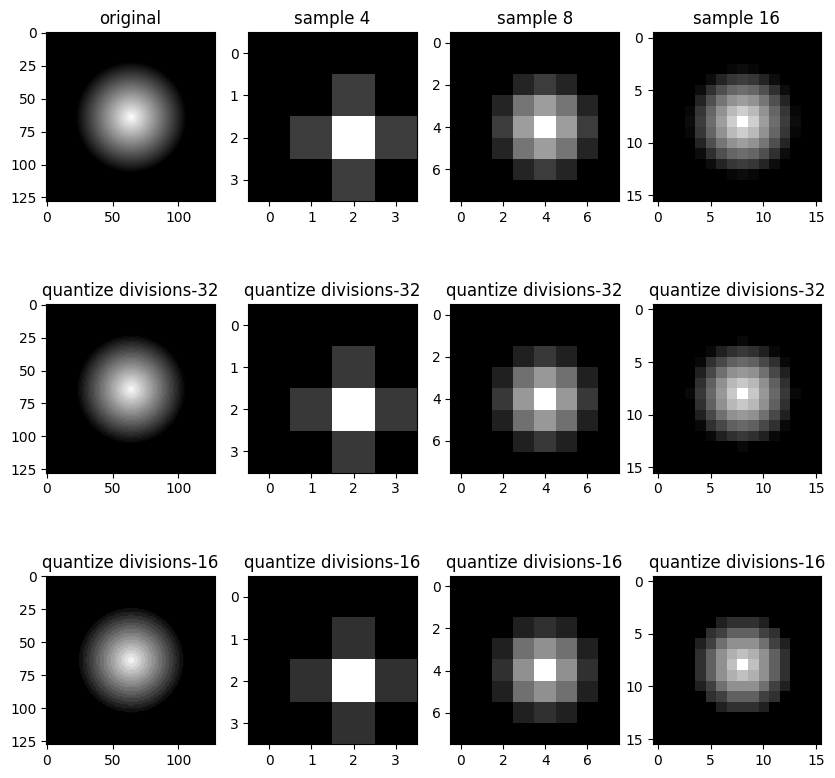

In [56]:
# img = sampleCirlce()
# img = quantize(img, 8)
# plt.imshow(img, cmap='gray')
img = createCircle()

imgs = [img]
title = ['original']
for i in range(1, 4):
    imgs.append(sampleCircle(img, 2**(i+1), 2**(i+1)))
    title.append(f'sample {2**(i+1)}')

for i in range(5, 1, -1):
    for j in range(len(imgs)):
        imgs.append(quantize(imgs[j], div=2**i))
        title.append(f"quantize divisions-{2**i}")

plot(3,4, imgs, title)



## Basic Image Manipulation ( resize, crop, rotate, flip, annotate )

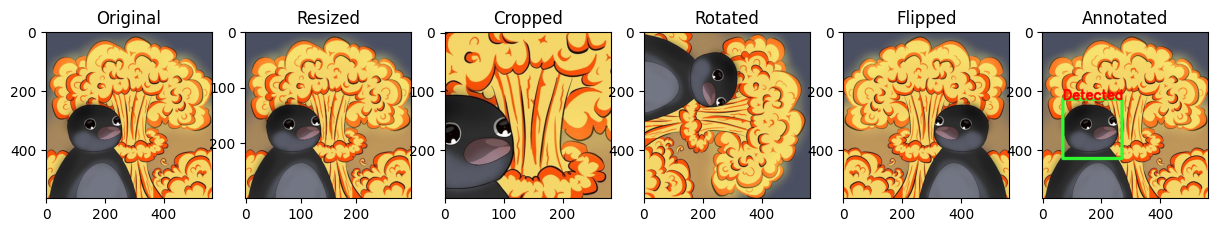

In [22]:
img = cv2.imread('wow.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

resized = cv2.resize(img, (300, 300))
crop = img[h//4:h*3//4, w//4:w*3//4]
rotated = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
flipped = cv2.flip(img, 1)
annotated = img.copy()
cv2.rectangle(annotated, (70, 230), (270, 430), (50, 250, 50), 10)
cv2.putText(annotated, "Detected", (70, 230), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 0, 0), 5)

plt.figure(figsize=(15, 15))
for i, [title, img] in enumerate([
        ("Original", img),
        ("Resized", resized),
        ("Cropped", crop),
        ("Rotated", rotated),
        ("Flipped", flipped),
        ("Annotated", annotated),
    ]):
    plt.subplot(1, 6, i+1)
    plt.imshow(img)
    plt.title(title)

## Pixel Neighbourhood Analysis ( connectivity, distace measure )

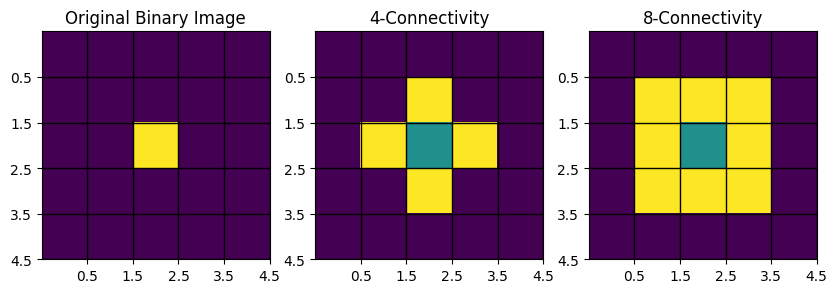

In [23]:
img = np.zeros((5, 5), dtype=np.uint8)
selected = (2, 2)
img[*selected] = 1

four_connected = np.copy(img)
eight_connected = np.copy(img)

for i in range(len(img)):
    for j in range(len(img[0])):
        dist = np.sqrt((selected[0] - i)**2 + abs(selected[1] - j)**2)
        if dist and dist < 2:
            eight_connected[i][j] = 2
            if dist == 1:
                four_connected[i][j] = 2

plt.figure(figsize=(10, 10))
for i, [img, title] in enumerate([(img, 'Original Binary Image'),
                       (four_connected, '4-Connectivity'),
                       (eight_connected, '8-Connectivity')]):
    ax = plt.subplot(1, 3, i + 1)
    ax.imshow(img)
    ax.set_title(title)
    ax.set_xticks(np.arange(0.5, 5, 1))
    ax.set_yticks(np.arange(0.5, 5, 1))
    ax.grid(True, color='black', linewidth=1)

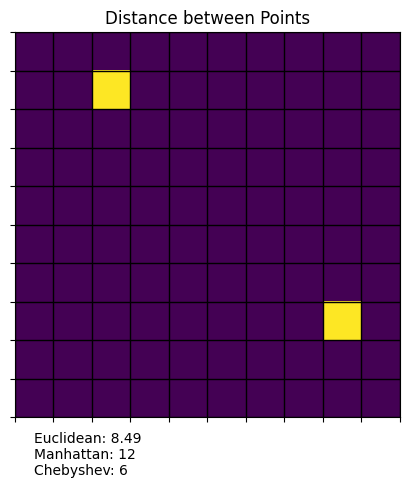

In [24]:
img = np.zeros((10, 10), dtype=np.uint8)

p1 = (1, 2)
p2 = (7, 8)

img[p1] = 1
img[p2] = 1

euclidean_dist = np.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2)
manhattan_dist = abs(p2[0] - p1[0]) + abs(p2[1] - p1[1])
chebyshev_dist = max(abs(p2[0] - p1[0]), abs(p2[1] - p1[1]))

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title('Distance between Points')

plt.grid(True, color='black', linewidth=1)
plt.xticks(np.arange(-0.5, 10.5, 1), [])
plt.yticks(np.arange(-0.5, 10.5, 1), [])

plt.text(0, 11, f'Euclidean: {euclidean_dist:.2f}\nManhattan: {manhattan_dist}\nChebyshev: {chebyshev_dist}')
plt.show()